In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.data.preprocessing import *

In [3]:
import src.utils.dataset_analyzer as analyzer

dataset_path = PROJECT_ROOT/"data/raw/RML2016.10a_dict.pkl"

dataset = analyzer.load_dataset(dataset_path)

2026-06-29 16:28:40,502 | INFO | Loading dataset...
2026-06-29 16:28:46,197 | INFO | Dataset loaded successfully.


In [4]:
first_key = list(dataset.keys())[0]

signal = dataset[first_key][0]

print(signal.shape)

(2, 128)


In [5]:
I,Q = split_iq(signal)

print(I.shape)

print(Q.shape)

(128,)
(128,)


In [6]:
normalized = normalize_iq(signal)

print(normalized.shape)

(2, 128)


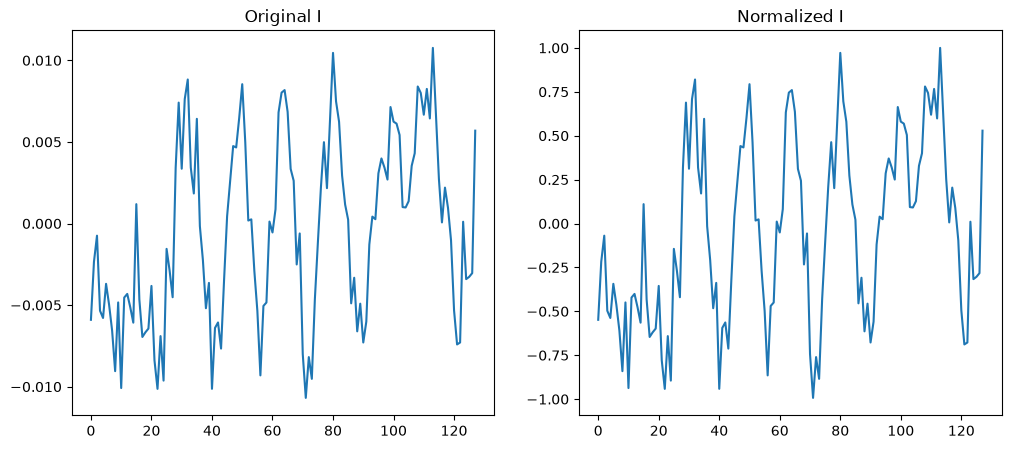

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(signal[0])

plt.title("Original I")

plt.subplot(1,2,2)

plt.plot(normalized[0])

plt.title("Normalized I")

plt.show()

In [8]:
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "Original_VS_Normalized.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [9]:
first_key = list(dataset.keys())[0]

signal = dataset[first_key][0]

In [10]:
amplitude = calculate_amplitude(signal)

print(amplitude.shape)

(128,)


In [11]:
phase = calculate_phase(signal)

print(phase.shape)

(128,)


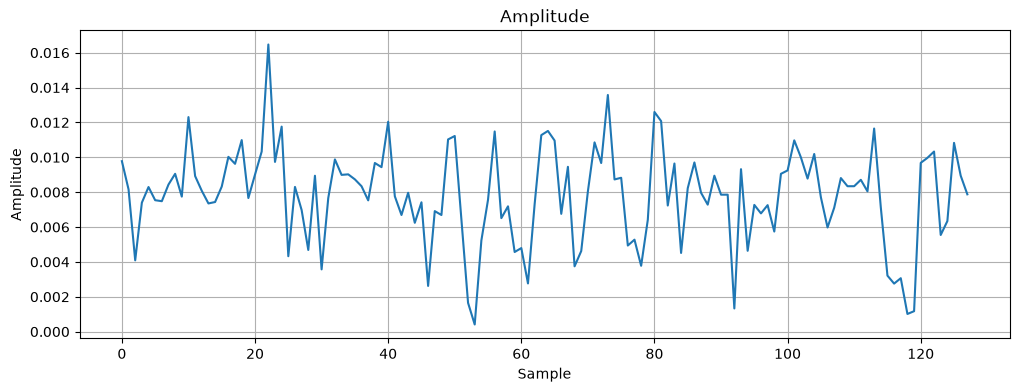

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(amplitude)

plt.title("Amplitude")

plt.xlabel("Sample")

plt.ylabel("Amplitude")

plt.grid(True)

plt.show()

In [13]:
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "Amplitude.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

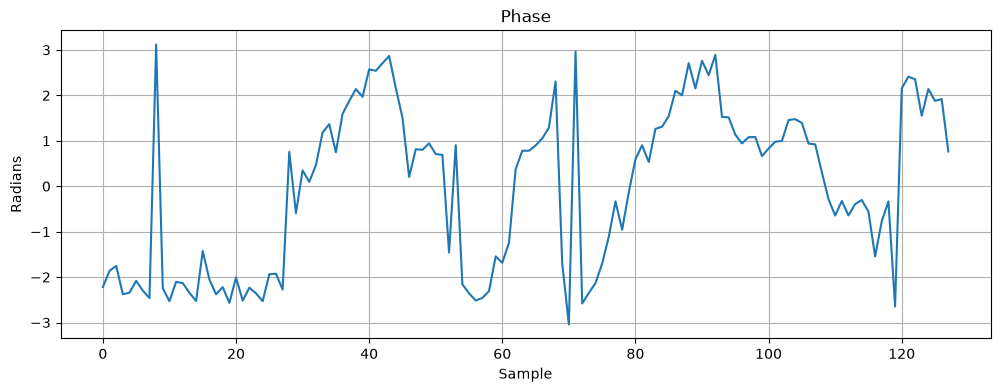

In [14]:
plt.figure(figsize=(12,4))

plt.plot(phase)

plt.title("Phase")

plt.xlabel("Sample")

plt.ylabel("Radians")

plt.grid(True)

plt.show()

In [15]:
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "Phase.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [16]:
fft = calculate_fft(signal)

print(fft.shape)

(128,)


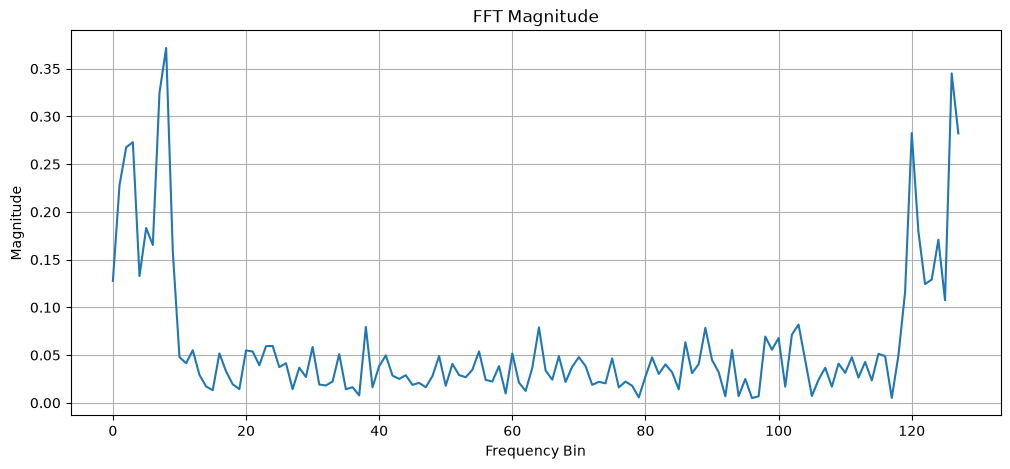

In [17]:
plt.figure(figsize=(12,5))

plt.plot(fft)

plt.title("FFT Magnitude")

plt.xlabel("Frequency Bin")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

In [18]:
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "fft_magnitude.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

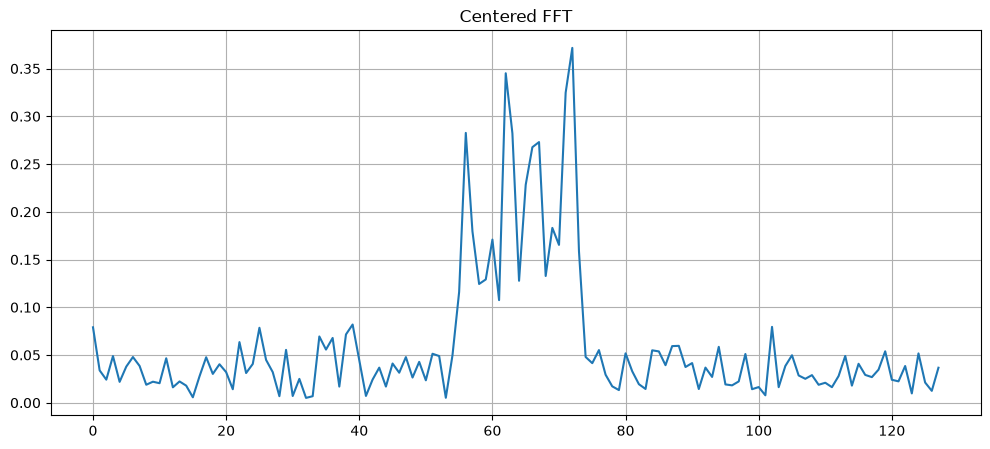

In [19]:
shifted = calculate_fft_shifted(signal)

plt.figure(figsize=(12,5))

plt.plot(shifted)

plt.title("Centered FFT")

plt.grid(True)

plt.show()

In [20]:
plt.savefig(
    PROJECT_ROOT / "results" / "figures" / "Centered_fft_magnitude.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

<Figure size 640x480 with 0 Axes>

In [21]:
psd = calculate_psd(signal)

print(psd.shape)

(128,)


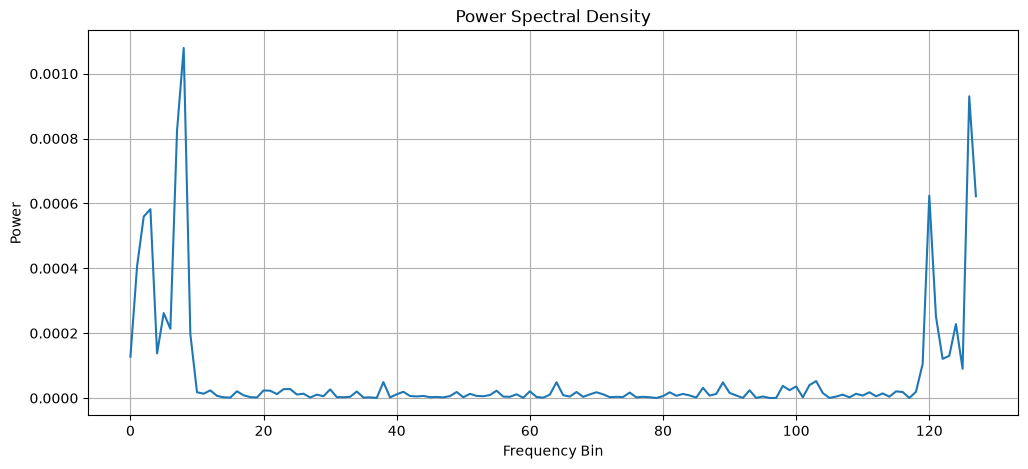

In [22]:
plt.figure(figsize=(12,5))

plt.plot(psd)

plt.title("Power Spectral Density")

plt.xlabel("Frequency Bin")

plt.ylabel("Power")

plt.grid(True)

plt.show()

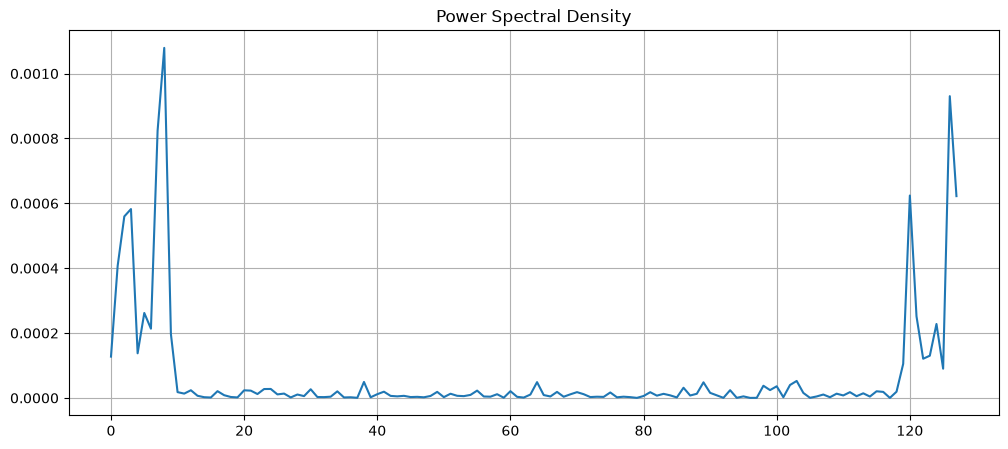

In [23]:
FIGURE_PATH = PROJECT_ROOT/"results"/"figures"

FIGURE_PATH.mkdir(parents=True,exist_ok=True)

plt.figure(figsize=(12,5))

plt.plot(psd)

plt.title("Power Spectral Density")

plt.grid(True)

plt.savefig(
    FIGURE_PATH/"power_spectral_density.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

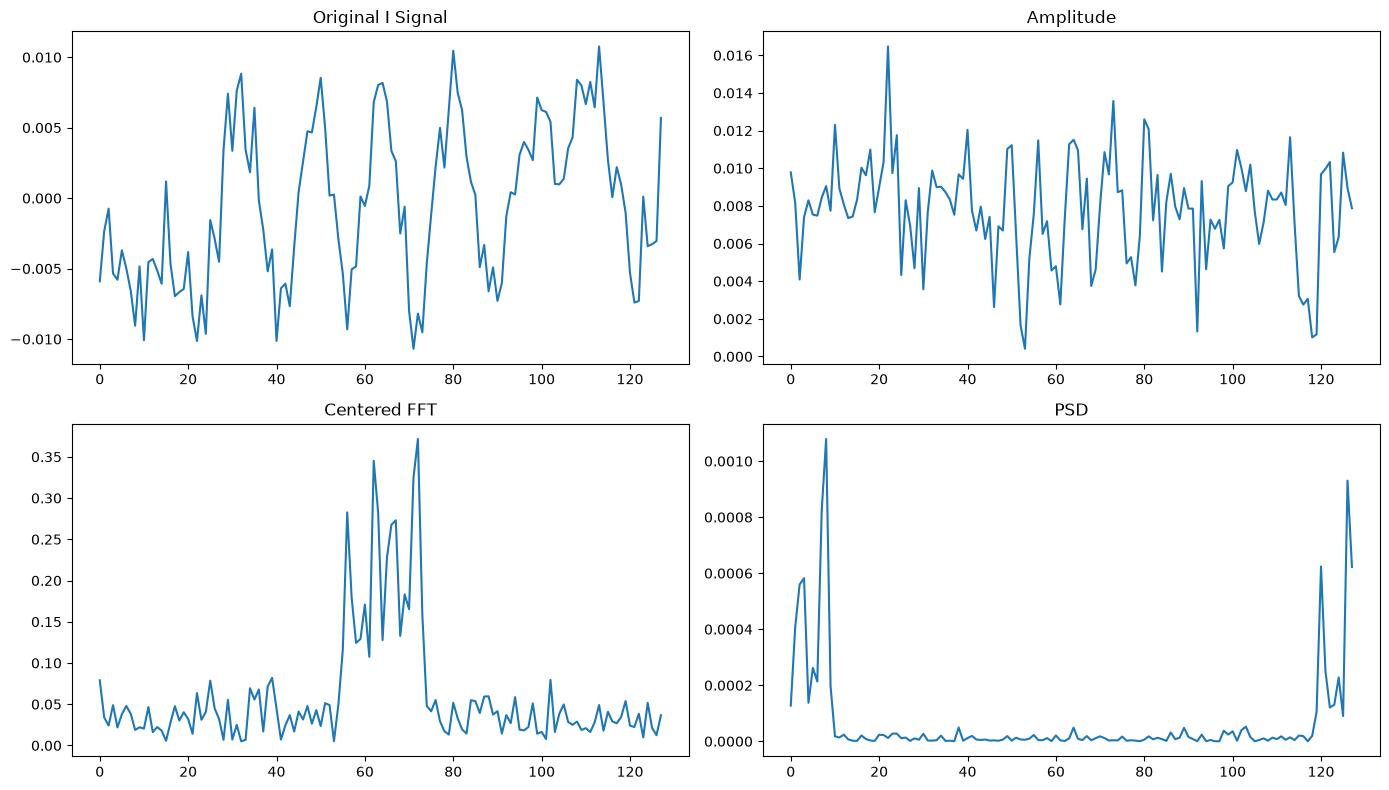

In [24]:
fig, ax = plt.subplots(2,2, figsize=(14,8))

ax[0,0].plot(signal[0])
ax[0,0].set_title("Original I Signal")

ax[0,1].plot(amplitude)
ax[0,1].set_title("Amplitude")

ax[1,0].plot(shifted)
ax[1,0].set_title("Centered FFT")

ax[1,1].plot(psd)
ax[1,1].set_title("PSD")

plt.tight_layout()
plt.show()

In [25]:
noisy_signal = add_awgn_noise(signal, snr_db=5)

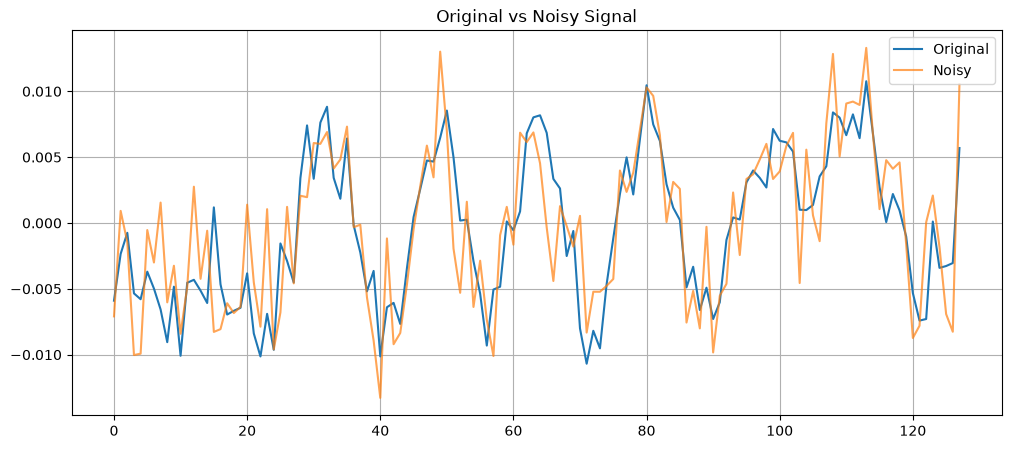

In [26]:
plt.figure(figsize=(12,5))

plt.plot(signal[0], label="Original")

plt.plot(noisy_signal[0], label="Noisy", alpha=0.7)

plt.legend()

plt.title("Original vs Noisy Signal")

plt.grid(True)

plt.show()

In [27]:
plt.savefig(
    FIGURE_PATH/"Original_VS_noisy_signal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>